In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import io # Import io module for BytesIO

# Load data
from google.colab import files
uploaded = files.upload()

# Read the uploaded CSV into a DataFrame
# Assuming only one file is uploaded and it's a CSV
for fn in uploaded.keys():
    df = pd.read_csv(io.BytesIO(uploaded[fn]))

# Basic checks
df.head()
df.info()
df.isnull().sum()
df.duplicated().sum()

# Clean data
df = df.drop_duplicates()

# Fill missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Optional: drop cabin if too many missing values
if 'Cabin' in df.columns:
    df = df.drop(columns=['Cabin'])

# Summary stats
df.describe()

Saving Titanic_visu - Titanic_visu (2).csv to Titanic_visu - Titanic_visu (2) (1).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  25 non-null     int64  
 1   Survived    25 non-null     int64  
 2   Pclass      25 non-null     int64  
 3   Name        25 non-null     object 
 4   Sex         25 non-null     object 
 5   Age         25 non-null     int64  
 6   Ticket      25 non-null     object 
 7   Fare        25 non-null     float64
 8   Embarked    25 non-null     object 
 9   Concession  25 non-null     float64
 10  New_Fare    25 non-null     float64
dtypes: float64(3), int64(4), object(4)
memory usage: 2.3+ KB


,Unnamed: 0,Survived,Pclass,Age,Fare,Concession,New_Fare
count,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000
mean,12.000000,0.520000,2.400000,36.160000,21.903664,17.604000,25.599480
std,7.359801,0.509902,0.816497,11.130588,16.673578,1.240121,19.273926
min,0.000000,0.000000,1.000000,20.000000,7.225000,16.000000,8.670000
25%,6.000000,0.000000,2.000000,26.000000,8.050000,16.400000,9.555350
50%,12.000000,1.000000,3.000000,35.000000,16.700000,17.400000,19.605800
75%,18.000000,1.000000,3.000000,43.000000,29.125000,18.700000,33.901500
max,24.000000,1.000000,3.000000,58.000000,71.283300,20.000000,82.688628


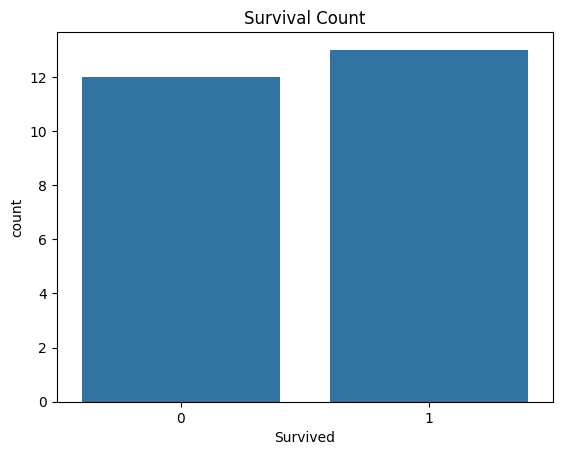

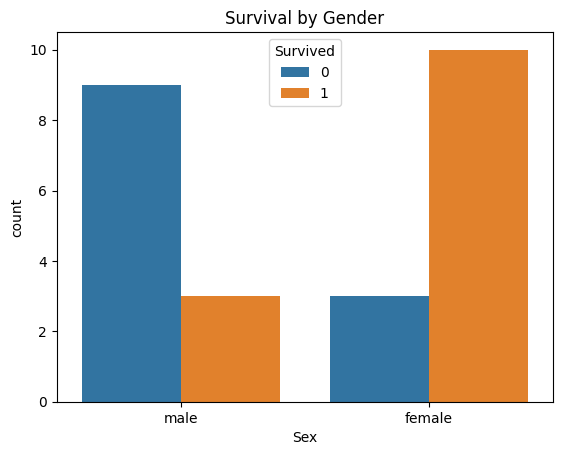

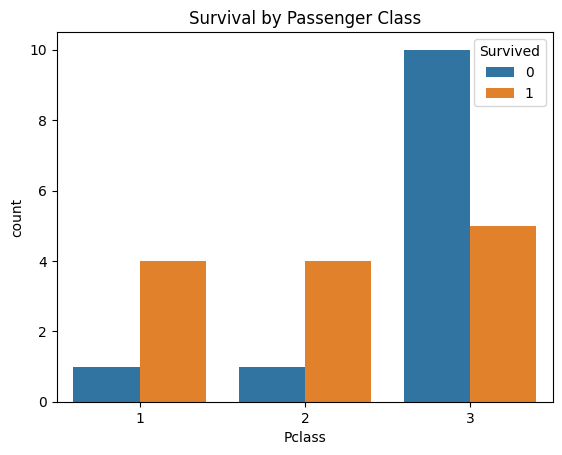

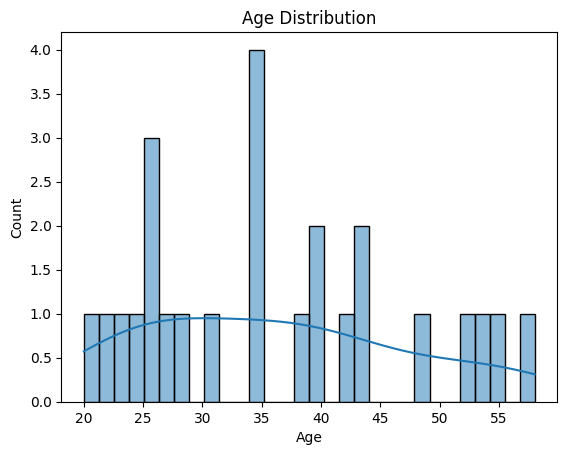

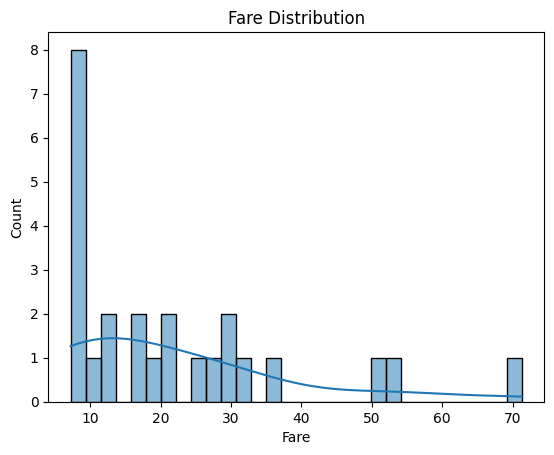

In [4]:
sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.show()

sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival by Gender')
plt.show()

sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival by Passenger Class')
plt.show()

sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

sns.histplot(df['Fare'], bins=30, kde=True)
plt.title('Fare Distribution')
plt.show()

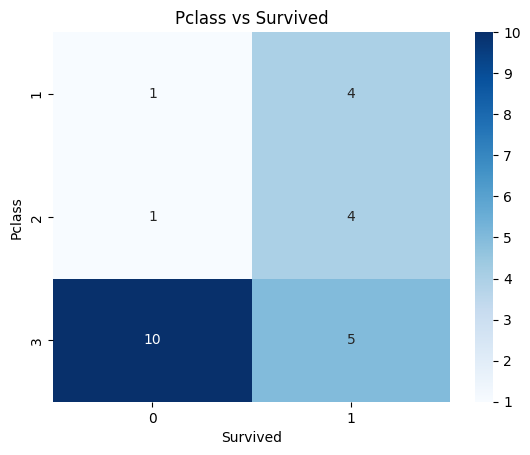

In [5]:
pivot = df.groupby(['Pclass', 'Survived']).size().unstack()
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues')
plt.title('Pclass vs Survived')
plt.show()